# 일별 개수 라벨만 있을 때의 용접 불량 예측: 데이터 진단과 검증 전략

`result` 시트는 **용접 1건마다의 불량 여부가 아니라, 일자별·유형별 불량 개수(8일 × 3유형 = 24개 숫자)** 만 제공합니다.
이 노트북은 다음 순서로 "무엇을 기준으로 모델을 검증해야 하는가"를 정리합니다.

1. **데이터 구조 진단**: 9일치 데이터가 서로 독립적인지 확인합니다.
2. **이론적 최소 오차**: 공정 변수만 보는 모델이 일별·유형별 개수를 얼마나 맞출 수 있는지, 그 하한을 정수계획(MILP)으로 계산합니다.
3. **라벨의 정보량**: 하루치 라벨을 빼고 나머지 7일로 그날의 개수를 맞혀 보는 Leave-one-day-out 검증입니다.
4. **권장 검증(합성 불량 주입)**: 정답을 알고 있는 가짜 불량을 넣어 탐지 한계(실패조건)를 측정합니다.
5. **실제 데이터 적용과 안정 공정 범위**

> 필요 패키지: `pandas`, `numpy`, `scipy>=1.9`(`milp`), `scikit-learn`, `matplotlib`, `openpyxl`

In [1]:
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import Bounds, LinearConstraint, linear_sum_assignment, milp, minimize
from scipy.sparse import csr_matrix, lil_matrix
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# 차트 색상 (범주형 3색, 색각이상 검증 완료)
C1, C2, C3 = '#2a78d6', '#eb6834', '#1baf7a'
GRID, INK2 = '#e4e3df', '#52514e'
plt.rcParams.update({'axes.edgecolor': GRID, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
                     'axes.spines.top': False, 'axes.spines.right': False, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.labelcolor': INK2, 'axes.titlesize': 11, 'font.size': 9})

PATH = Path('dataset') / 'Welding Data Set_01.xlsx'
F = ['force', 'current', 'voltage', 'wtime']
TYPES = {1: '파임불량', 2: '용접부족', 3: '크랙발생'}

raw = pd.read_excel(PATH, sheet_name=0)
raw.columns = ['idx', 'machine', 'item', 'date', 't1', 't2'] + F
raw[F] = raw[F].round(3)                       # 부동소수 오차 제거 (예: 2.3600000000000003)
raw['d'] = raw['date'].dt.strftime('%m-%d')

res = pd.read_excel(PATH, sheet_name=1)
res.columns = ['i', 'machine', 'item', 'date', 'defect', 'dtype', 'name']
Y_raw = res.pivot_table(index='date', columns='dtype', values='defect', aggfunc='sum')
Y_raw.index = Y_raw.index.strftime('%m-%d')
Y = Y_raw.fillna(0)                            # 03-31 유형3 행이 없음 → 0으로 가정 (아래에서 '미상' 가정도 비교)
LAB_DAYS = list(Y.index)
ALL_DAYS = sorted(raw['d'].unique())
print('라벨 없는 날:', sorted(set(ALL_DAYS) - set(LAB_DAYS)))
display(pd.concat([Y_raw, raw.groupby('d').size().rename('n_welds')], axis=1))

라벨 없는 날: ['03-27']


,1,2,3,n_welds
03-24,2.0,1.0,1.0,1200
03-25,3.0,2.0,3.0,1352
03-26,3.0,2.0,2.0,1000
03-30,1.0,2.0,1.0,1470
03-31,2.0,3.0,NaN,1800
04-02,1.0,1.0,2.0,2000
04-03,2.0,1.0,1.0,800
04-07,0.0,1.0,2.0,669
03-27,NaN,NaN,NaN,1648


## 1. 데이터 구조 진단: 9일치는 독립적인 9일이 아니다

### 1-1. 서로 다른 (가압력, 전류, 전압, 통전시간) 조합의 수

In [2]:
raw['vid'] = pd.factorize(pd.Series(list(zip(*[raw[c] for c in F]))))[0]
print(f"전체 {len(raw):,}행 중 서로 다른 4변수 조합: {raw['vid'].nunique():,}개")
display(raw.groupby('d')[F].agg(['min', 'median', 'max']).round(3))

전체 11,939행 중 서로 다른 4변수 조합: 1,574개


force               current                voltage               wtime             
        min median    max     min  median    max     min median    max   min median   max
d                                                                                        
03-24  2.16  2.330   2.40   14.52  14.720  14.97   2.689  2.702  2.717  70.0   72.0  73.0
03-25  1.74  2.350  10.54   14.52  14.740  15.07   2.464  2.702  2.861  70.0   72.0  73.0
03-26  2.30  2.350   2.39   14.52  14.620  14.78   2.691  2.701  2.713  70.0   72.0  73.0
03-27  1.74  2.320  10.54   14.52  14.750  15.07   2.464  2.703  2.861  70.0   72.0  73.0
03-30  2.30  2.350   2.39   14.52  14.700  14.78   2.691  2.701  2.713  70.0   72.0  73.0
03-31  1.74  2.320  10.54   14.52  14.740  15.07   2.464  2.702  2.861  70.0   72.0  73.0
04-02  2.25  2.330   2.39   14.52  14.730  14.81   2.691  2.702  2.717  70.0   72.0  73.0
04-03  1.74  2.425  10.54   14.52  14.785  15.07   2.464  2.703  2.861  70.0   72.0  73.0
04-07  2.30  2.350   2.39   14.53  14.610  14.77   2.691  2.701  2.713  70.0   72.0  73.0

03-25, 03-27, 03-31, 04-03 네 날짜에만 가압력 최대 10.54 bar, 전압 2.464~2.861 V 같은 극단값이 **완전히 같은 값으로** 나타납니다.
연속된 6행이 다른 위치와 통째로 일치하는지 해시로 찾아 **복사된 구간**을 추적합니다.

In [3]:
def find_copy_segments(df, k=6, min_len=15):
    # 연속 k행이 완전히 같은 구간을 찾아, 같은 '복사 관계'가 유지되는 최대 구간으로 묶는다
    X = df[F].values; day = df['d'].values; idx = df['idx'].values; N = len(X)
    table = defaultdict(list)
    for i in range(N - k + 1):
        if day[i] == day[i + k - 1]:
            table[X[i:i + k].tobytes()].append(i)
    partners = [set() for _ in range(N)]        # 행 i와 같은 내용이 (i + offset) 위치에 있음
    for locs in table.values():
        if len(locs) > 1:
            for a in locs:
                for b in locs:
                    if a != b:
                        for r in range(a, a + k):
                            partners[r].add(b - a)
    segs, s = [], 0
    for i in range(1, N + 1):
        if i == N or partners[i] != partners[i - 1] or day[i] != day[i - 1]:
            segs.append(dict(day=day[s], idx_from=idx[s], idx_to=idx[i - 1], length=i - s,
                             mean_force=X[s:i, 0].mean().round(2), n_copies=len(partners[s]),
                             copies=', '.join(sorted({f'{day[s + o]}@{idx[s + o]}' for o in partners[s]}))))
            s = i
    shared = np.array([len(p) > 0 for p in partners])
    return pd.DataFrame(segs), shared

segs, shared = find_copy_segments(raw)
raw['shared'] = shared
print(f"다른 위치에 동일한 6행 이상 구간이 존재하는 행: {shared.sum():,} / {len(raw):,} ({shared.mean():.1%})")
display(raw.groupby('d')['shared'].agg(rows='size', shared_rows='sum'))
long_segs = segs[segs.length >= 300]
display(long_segs[['day', 'idx_from', 'idx_to', 'length', 'mean_force', 'copies']])

다른 위치에 동일한 6행 이상 구간이 존재하는 행: 11,693 / 11,939 (97.9%)


,rows,shared_rows
d,,
03-24,1200,956
03-25,1352,1350
03-26,1000,1000
03-27,1648,1648
03-30,1470,1470
03-31,1800,1800
04-02,2000,2000
04-03,800,800
04-07,669,669


,day,idx_from,idx_to,length,mean_force,copies
21,03-24,793,1200,408,2.31,"03-27@57, 03-31@47, 04-02@1323"
22,03-25,1,975,975,3.71,"03-27@465, 03-31@455, 04-02@1731"
73,03-27,57,1439,1383,3.30,"03-24@793, 03-31@47, 04-02@1323"
133,03-31,47,1429,1383,3.30,"03-24@793, 03-27@57, 04-02@1323"
192,04-02,1323,2000,678,2.30,"03-24@793, 03-27@57, 03-31@47"
193,04-03,1,705,705,4.25,"03-25@271, 03-27@735, 03-31@725"


- 03-24의 일부(약 240행)를 제외하면 **거의 모든 행이 다른 날짜에 똑같이 존재**합니다.
- 짧은 구간(147·25·22·31·66·29·42·85행)이 거의 모든 날짜에 반복되고, 04-07은 25·22·29행짜리 구간이 5~6번 반복된 형태입니다.
- 고가압 이상 구간은 03-27 idx 57~1439의 긴 구간 안에 있고, 03-25·03-31·04-03에 그대로 복사되어 있습니다.

즉 이 데이터는 **소수의 원본 구간을 잘라 붙여 만든 것**입니다. 이 사실은 모델링과 검증 방식을 크게 바꿉니다.

### 1-2. 날짜 간 포함관계: 라벨과 직접 충돌하는 쌍

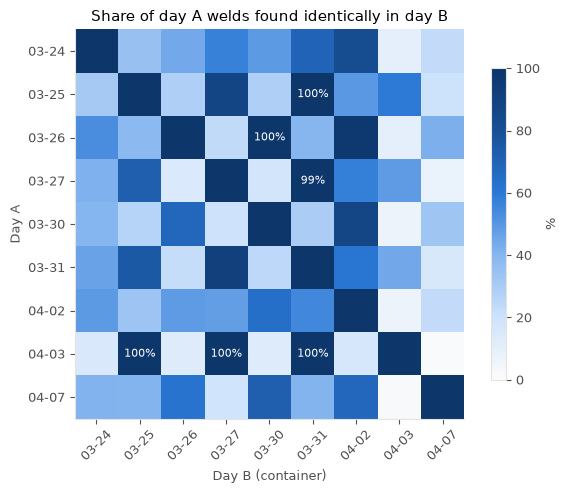

,A,B,share,defects_A,defects_B
0,03-25,03-31,99.6%,8.0,5.0
1,03-26,03-30,100.0%,7.0,4.0
2,03-27,03-31,99.5%,NaN,5.0
3,04-03,03-25,100.0%,4.0,8.0
4,04-03,03-27,100.0%,4.0,NaN
5,04-03,03-31,100.0%,4.0,5.0


In [4]:
M = pd.crosstab(raw['d'], raw['vid'])                 # (일자 × 고유 벡터) 출현 횟수
cover = pd.DataFrame({b: [np.minimum(M.loc[a], M.loc[b]).sum() / M.loc[a].sum() for a in ALL_DAYS] for b in ALL_DAYS},
                     index=ALL_DAYS)                 # A행의 데이터 중 B에 그대로 포함된 비율

blues = LinearSegmentedColormap.from_list('blues', ['#fcfcfb', '#cde2fb', '#86b6ef', '#2a78d6', '#184f95', '#0d366b'])
fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(cover.values * 100, cmap=blues, vmin=0, vmax=100)
ax.set_xticks(range(len(ALL_DAYS)), ALL_DAYS, rotation=45); ax.set_yticks(range(len(ALL_DAYS)), ALL_DAYS)
ax.grid(False)
for i, a in enumerate(ALL_DAYS):
    for j, b in enumerate(ALL_DAYS):
        if i != j and cover.loc[a, b] >= 0.99:
            ax.text(j, i, f'{cover.loc[a, b]:.0%}', ha='center', va='center', color='white', fontsize=8)
ax.set_xlabel('Day B (container)'); ax.set_ylabel('Day A')
ax.set_title('Share of day A welds found identically in day B')
fig.colorbar(im, ax=ax, label='%', shrink=0.8)
plt.tight_layout(); plt.show()

tot = Y.sum(axis=1)
rows = [dict(A=a, B=b, share=f'{cover.loc[a, b]:.1%}', defects_A=tot.get(a, np.nan), defects_B=tot.get(b, np.nan))
        for a in ALL_DAYS for b in ALL_DAYS if a != b and cover.loc[a, b] >= 0.99]
display(pd.DataFrame(rows))

**03-26의 용접 데이터 1000건 전부가 03-30에 같은 값으로 들어 있습니다.** 그런데 불량 수는 03-26이 7건, 03-30이 4건입니다.
입력이 같으면 출력도 같은 모델이라면 결정론적이든 확률적이든 항상 `예측(03-30) ≥ 예측(03-26)`이 됩니다. 따라서 **두 날짜의 개수를 동시에 맞추는 모델은 존재할 수 없습니다.**
03-25(8건)와 03-31(5건)도 마찬가지입니다. 03-25의 99.6%가 03-31에 포함되어 있습니다.

## 2. 이론적 최소 오차: 어떤 모델도 넘을 수 없는 하한

고유 벡터마다 불량 유형 z ∈ {0,1}³을 하나씩 정하는 **완벽한 오라클**을 가정합니다.
이 오라클도 일별·유형별 개수 오차 Σ|예측−실제|를 얼마까지만 줄일 수 있는지 MILP로 계산합니다.

In [5]:
def fit_counts(train_days, Y, prior=None, eps=1e-4, merge_types=False, time_limit=60):
    # 개수 오차 최소화 MILP. prior(고유벡터×유형 점수)가 있으면 오차가 같은 해 중 물리적으로 그럴듯한 해를 고른다.
    Ml = M.loc[train_days].values.astype(float); C = Ml.shape[1]; D = len(train_days)
    T = 1 if merge_types else 3
    nz, ne = C * T, D * T; nv = nz + 2 * ne
    A = lil_matrix((D * T + (C if T > 1 else 0), nv)); lb, ub = [], []; k = 0
    for t in range(T):
        for di, d in enumerate(train_days):
            y = Y.loc[d].sum() if merge_types else Y.loc[d, t + 1]
            A[k, t * C:(t + 1) * C] = Ml[di]
            if np.isnan(y):                          # 미상 라벨은 제약하지 않음
                lb.append(0); ub.append(np.inf)
            else:
                A[k, nz + t * D + di] = -1; A[k, nz + ne + t * D + di] = 1
                lb.append(y); ub.append(y)
            k += 1
    if T > 1:                                        # 한 벡터는 최대 한 유형
        for c in range(C):
            for t in range(T):
                A[k, c + t * C] = 1
            lb.append(0); ub.append(1); k += 1
    p = np.zeros(nz) if prior is None else prior.loc[M.columns].values.T.ravel() / prior.values.max()
    cost = np.r_[eps * (1.01 - p), np.ones(2 * ne)]   # 1순위: 개수 오차, 2순위: 불량 수 최소, 3순위: prior
    bounds = Bounds(np.zeros(nv), np.r_[np.ones(nz), np.full(2 * ne, np.inf)])
    r = milp(c=cost, constraints=LinearConstraint(csr_matrix(A), lb, ub),
             integrality=np.r_[np.ones(nz), np.zeros(2 * ne)], bounds=bounds, options={'time_limit': time_limit})
    z = pd.DataFrame(np.round(r.x[:nz]).reshape(T, C).T, index=M.columns, columns=[0] if merge_types else [1, 2, 3])
    return z

def predict_counts(z, days):
    return pd.DataFrame(M.loc[days].values @ z.values, index=days, columns=z.columns)

for name, Yx in [('03-31 유형3 = 0', Y), ('03-31 유형3 = 미상', Y_raw)]:
    z = fit_counts(LAB_DAYS, Yx)
    p = predict_counts(z, LAB_DAYS)
    err = np.nansum(np.abs(p.values - Yx.values))
    print(f'[{name}] 유형별 개수 최소 오차 = {err:.0f}  (총 불량 {np.nansum(Yx.values):.0f}건)')
    display(pd.concat([Yx.add_prefix('실제_'), p.add_prefix('오라클_')], axis=1))

z_tot = fit_counts(LAB_DAYS, Y, merge_types=True)
p_tot = predict_counts(z_tot, LAB_DAYS)[0]
print(f"[유형 무시, 일별 총계] 최소 오차 = {np.abs(p_tot - Y.sum(axis=1)).sum():.0f}")
display(pd.DataFrame({'실제': Y.sum(axis=1), '오라클': p_tot}))

[03-31 유형3 = 0] 유형별 개수 최소 오차 = 10  (총 불량 39건)


,실제_1,실제_2,실제_3,오라클_1,오라클_2,오라클_3
03-24,2.0,1.0,1.0,2.0,1.0,1.0
03-25,3.0,2.0,3.0,2.0,2.0,3.0
03-26,3.0,2.0,2.0,2.0,2.0,2.0
03-30,1.0,2.0,1.0,2.0,2.0,2.0
03-31,2.0,3.0,0.0,2.0,2.0,2.0
04-02,1.0,1.0,2.0,2.0,2.0,2.0
04-03,2.0,1.0,1.0,2.0,1.0,1.0
04-07,0.0,1.0,2.0,0.0,1.0,1.0


[03-31 유형3 = 미상] 유형별 개수 최소 오차 = 8  (총 불량 39건)


,실제_1,실제_2,실제_3,오라클_1,오라클_2,오라클_3
03-24,2.0,1.0,1.0,2.0,1.0,1.0
03-25,3.0,2.0,3.0,2.0,2.0,3.0
03-26,3.0,2.0,2.0,2.0,2.0,2.0
03-30,1.0,2.0,1.0,2.0,3.0,2.0
03-31,2.0,3.0,NaN,2.0,2.0,2.0
04-02,1.0,1.0,2.0,2.0,1.0,2.0
04-03,2.0,1.0,1.0,2.0,1.0,1.0
04-07,0.0,1.0,2.0,0.0,1.0,1.0


[유형 무시, 일별 총계] 최소 오차 = 6


,실제,오라클
03-24,4.0,4.0
03-25,8.0,7.0
03-26,7.0,4.0
03-30,4.0,4.0
03-31,5.0,6.0
04-02,4.0,4.0
04-03,4.0,4.0
04-07,3.0,4.0


- 4개 공정 변수만 보는 모델은 **완벽하더라도 24칸 합계 오차 10(03-31 유형3을 미상으로 두면 8), 일별 총계 오차 6**을 넘어설 수 없습니다.
- 지금까지 Autoencoder나 Isolation Forest의 **일별 개수가 맞지 않은 것은 모델 탓만이 아닙니다.** 데이터와 라벨의 구조상 정확히 맞추는 것 자체가 불가능합니다.
- 모델 비교는 "실제와 일치하는가"가 아니라 **"이 하한에 얼마나 가까운가"** 로 보고해야 공정합니다.

## 3. 일별 개수 라벨은 모델을 가려낼 수 있는가? (라벨 Leave-one-day-out)

하루치 라벨을 가리고 나머지 7일의 라벨로 모델을 만든 뒤, 가린 날의 유형별 개수를 예측합니다. 날짜끼리 데이터를 공유하므로 **데이터를 나누는 CV가 아니라 라벨(제약)만 빼는 방식**입니다.

- A. 평균 예측: 7일 평균 개수를 그대로 사용(정보 없음 기준선)
- B. 일정 불량률: 용접 1건당 불량률 × 그날 용접 수
- C. MILP 개수 적합: 7일 개수를 최소 오차로 맞추는 벡터 선택
- D. MILP + 물리 prior: C와 같되, 오차가 같은 해 중 용접 물리와 맞는 해 선택
- E. LLP 로지스틱: p(불량|x)=sigmoid(w·z(x))를 일별 개수의 Poisson 우도로 학습(Learning from Label Proportions)

In [6]:
U = raw.groupby('vid')[F].first()
med = raw[F].median(); mad = 1.4826 * (raw[F] - med).abs().median()
mad = mad.where(mad > 0, raw[F].std())            # 통전시간은 절반 이상이 72ms라 MAD=0
Zu = ((U - med) / mad).clip(-10, 10)
heat_u = U.current * U.voltage * U.wtime
zH = ((heat_u - heat_u.median()) / (1.4826 * (heat_u - heat_u.median()).abs().median())).clip(-10, 10)
relu = lambda s: s.clip(lower=0)
# 용접 물리 기반 유형 점수 (가설): 파임=과가압·과입열 / 용접부족=입열 부족 / 크랙=고저항·고전류·가압 부족
prior = pd.DataFrame({1: relu(Zu.force) + relu(zH),
                      2: relu(-zH) + relu(-Zu.current) + relu(-Zu.wtime),
                      3: relu(Zu.voltage) + relu(Zu.current) + relu(-Zu.force)})

Phi = pd.DataFrame({'zF': Zu.force, 'zI': Zu.current, 'zV': Zu.voltage, 'zT': Zu.wtime, 'zH': zH}).loc[M.columns].values

def fit_llp(train_days, l2=1.0):
    Ml = M.loc[train_days].values.astype(float); y = Y.loc[train_days].values; k = Phi.shape[1]
    def nll(theta):
        th = theta.reshape(3, k + 1); out = 0
        for t in range(3):
            lam = Ml @ (1 / (1 + np.exp(-(th[t, 0] + Phi @ th[t, 1:])))) + 1e-9
            out += (lam - y[:, t] * np.log(lam)).sum() + l2 * (th[t, 1:] ** 2).sum()
        return out
    th0 = np.zeros(3 * (k + 1)); th0[::k + 1] = -8
    th = minimize(nll, th0, method='L-BFGS-B').x.reshape(3, k + 1)
    return pd.DataFrame(np.stack([1 / (1 + np.exp(-(th[t, 0] + Phi @ th[t, 1:]))) for t in range(3)], 1),
                        index=M.columns, columns=[1, 2, 3])

rows = []
for hd in LAB_DAYS:
    tr = [d for d in LAB_DAYS if d != hd]; y = Y.loc[hd].values
    preds = {'A. 평균 예측': Y.loc[tr].mean().values,
             'B. 일정 불량률': (Y.loc[tr].sum() / M.loc[tr].values.sum() * M.loc[hd].sum()).values,
             'C. MILP 개수 적합': predict_counts(fit_counts(tr, Y), [hd]).iloc[0].values,
             'D. MILP + 물리 prior': predict_counts(fit_counts(tr, Y, prior), [hd]).iloc[0].values,
             'E. LLP 로지스틱': M.loc[hd].values @ fit_llp(tr).values}
    for m_, p in preds.items():
        rows.append(dict(day=hd, method=m_, type_err=np.abs(p - y).sum(), total_err=abs(p.sum() - y.sum())))
lodo = pd.DataFrame(rows)
display(lodo.pivot(index='day', columns='method', values='type_err').round(2))
display(lodo.groupby('method')[['type_err', 'total_err']].mean().round(2)
        .rename(columns={'type_err': '일평균 유형별 오차', 'total_err': '일평균 총계 오차'}))

method,A. 평균 예측,B. 일정 불량률,C. MILP 개수 적합,D. MILP + 물리 prior,E. LLP 로지스틱
day,,,,,
03-24,1.57,1.45,1.0,0.0,1.68
03-25,3.57,3.31,4.0,3.0,2.77
03-26,2.43,3.56,3.0,3.0,3.89
03-30,1.86,2.17,4.0,3.0,2.40
03-31,3.57,3.97,3.0,3.0,4.64
04-02,2.14,4.44,2.0,2.0,3.23
04-03,1.57,1.07,2.0,1.0,1.02
04-07,3.29,2.44,2.0,5.0,2.33


,일평균 유형별 오차,일평균 총계 오차
method,,
A. 평균 예측,2.50,1.54
B. 일정 불량률,2.80,2.19
C. MILP 개수 적합,2.62,1.62
D. MILP + 물리 prior,2.50,2.00
E. LLP 로지스틱,2.74,1.92


In [7]:
z_full = fit_counts(LAB_DAYS, Y, prior)
print('전체 8일 라벨로 적합한 MILP: 오차 =', np.abs(predict_counts(z_full, LAB_DAYS).values - Y.values).sum(),
      '| 불량으로 지정된 고유 벡터 수 =', int(z_full.values.sum()))
display(U.loc[z_full.index[z_full.sum(axis=1) > 0]].assign(type=z_full[z_full.sum(axis=1) > 0].idxmax(axis=1),
                                                        n_rows=M.sum()[z_full.index[z_full.sum(axis=1) > 0]]))

전체 8일 라벨로 적합한 MILP: 오차 = 10.0 | 불량으로 지정된 고유 벡터 수 = 6


,force,current,voltage,wtime,type,n_rows
vid,,,,,,
67,2.38,14.59,2.703,73.0,1,12
178,2.36,14.55,2.701,71.0,2,11
239,2.35,14.59,2.703,72.0,3,11
1283,9.01,14.75,2.464,71.0,2,4
1417,5.14,14.89,2.857,73.0,1,4
1519,7.91,15.07,2.753,72.0,3,4


- 라벨을 이용한 방법(C·D·E) 중 어느 것도 **"7일 평균을 그대로 찍는 A 기준선"보다 낫지 않습니다.** 공정 데이터와 일별 개수 사이에서 새로운 날로 일반화되는 신호를 찾을 수 없다는 뜻입니다.
- 전체 8일에 대해 하한(오차 10)을 달성하는 해는 **고유 벡터 6개만 불량으로 지정**하고, 복사 구조를 이용해 개수를 맞춥니다. 물리적 의미가 없는 해도 개수는 똑같이 잘 맞출 수 있으므로 **"일별 개수가 잘 맞는다"는 사실은 모델이 옳다는 근거가 되지 않습니다.**
- 따라서 일별 개수는 (1) 하한 대비 정합성 확인과 (2) 전체 경보율(임계값) 보정 **정도에만** 쓰고, 모델 선택과 검증은 아래의 **정답을 알고 있는 실험**으로 합니다.

## 4. 권장 검증: 합성 불량 주입(Inject-and-Detect)

1. **정상 기준 데이터**: 고가압 복사 구간이 없는 5일(03-24, 03-26, 03-30, 04-02, 04-07)의 데이터에서 **중복을 제거**합니다. 중복 제거 전에 나누면 같은 행이 train/test에 동시에 들어가는 누수가 생깁니다.
2. 이를 70/30으로 나눠 train으로 탐지기를 학습하고, test 정상 행에 **유형별 물리 패턴의 이상**을 크기 m(강건 표준편차 σ 배수)만큼 주입합니다.
   - 파임(1): 가압력 +mσ, 전류 +0.5mσ
   - 용접부족(2): 전류 −mσ, 통전시간 −0.5mσ
   - 크랙(3): 전압 +mσ, 가압력 −0.5mσ
3. 크기별·유형별 **재현율(탐지율)** 을 측정합니다. 재현율이 떨어지는 구간이 곧 **모델의 실패조건**이며, 과제가 요구하는 "모델의 실패조건 분석"에 그대로 대응합니다.

> 한계: 주입 패턴은 도메인 지식에 기반한 **가정**입니다. 이 실험은 "이런 형태·크기의 이탈을 잡을 수 있는가"를 검증하는 것이지, 가정 자체가 맞는지를 검증하지는 않습니다. 패턴은 현업/문헌 근거로 설명해야 합니다.

In [8]:
EXCURSION_DAYS = ['03-25', '03-27', '03-31', '04-03']       # 고가압 복사 구간이 들어있는 날
ref = raw[~raw['d'].isin(EXCURSION_DAYS)].drop_duplicates(F)[F].reset_index(drop=True)
rng = np.random.default_rng(0); perm = rng.permutation(len(ref)); ntr = int(0.7 * len(ref))
ref_tr, ref_te = ref.iloc[perm[:ntr]], ref.iloc[perm[ntr:]]

center = ref_tr.median(); scale = 1.4826 * (ref_tr - center).abs().median()
scale = scale.where(scale > 0, ref_tr.std())
zs = lambda X: (X[F].astype(float) - center) / scale
print('정상 기준 고유 행:', len(ref), '| 강건 σ:', scale.round(4).to_dict())

iforest = IsolationForest(n_estimators=300, random_state=0).fit(zs(ref_tr))
mcd = MinCovDet(random_state=0).fit(zs(ref_tr))
DETECTORS = {'IsolationForest': lambda X: -iforest.score_samples(zs(X)),
             'Robust Mahalanobis': lambda X: mcd.mahalanobis(zs(X))}
THR = {k: np.quantile(f(ref_tr), 0.995) for k, f in DETECTORS.items()}   # 정상 train 기준 상위 0.5%
print('held-out 정상 데이터의 오경보율:', {k: round(float((f(ref_te) > THR[k]).mean()), 4) for k, f in DETECTORS.items()})

PATTERN = {1: {'force': +1, 'current': +0.5}, 2: {'current': -1, 'wtime': -0.5}, 3: {'voltage': +1, 'force': -0.5}}
def inject(base, t, m):
    X = base.copy()
    for c, w in PATTERN[t].items():
        X[c] = X[c] + w * m * scale[c]
    return X

def physics_type(X):
    # 물리 규칙 기반 유형 판정 (GMM 대신)
    X = X[F].astype(float)
    feat = pd.DataFrame({**{c: X[c] for c in F}, 'heat': X.current * X.voltage * X.wtime, 'resist': X.voltage / X.current})
    base = ref_tr.astype(float)
    bfeat = pd.DataFrame({**{c: base[c] for c in F}, 'heat': base.current * base.voltage * base.wtime,
                          'resist': base.voltage / base.current})
    bmad = 1.4826 * (bfeat - bfeat.median()).abs().median()
    z = (feat - bfeat.median()) / bmad.where(bmad > 0, bfeat.std())
    s = pd.DataFrame({1: relu(z.force) + relu(z.heat),
                      2: relu(-z.heat) + relu(-z.current) + relu(-z.wtime),
                      3: relu(z.voltage) + relu(z.resist) + relu(-z.force)})
    return s.idxmax(axis=1).values

MAGS = [1, 2, 3, 4, 5, 6, 8, 10]
rec_rows, typ_rows = [], []
for m in MAGS:
    Xs, ys = [], []
    for t in (1, 2, 3):
        b = ref_te.sample(150, random_state=10 * m + t, replace=True)
        Xs.append(inject(b, t, m)); ys += [t] * len(b)
    Xs, ys = pd.concat(Xs), np.array(ys)
    for k, f in DETECTORS.items():
        hit = f(Xs) > THR[k]
        for t in (1, 2, 3):
            rec_rows.append(dict(m=m, detector=k, type=t, recall=hit[ys == t].mean()))
    gl = GaussianMixture(3, random_state=0, n_init=5).fit_predict(zs(Xs))
    cm = pd.crosstab(gl, ys).reindex(index=range(3), columns=[1, 2, 3], fill_value=0).values
    r_, c_ = linear_sum_assignment(-cm)
    typ_rows.append(dict(m=m, physics_rule=(physics_type(Xs) == ys).mean(), gmm_best_mapping=cm[r_, c_].sum() / len(ys)))
rec = pd.DataFrame(rec_rows)
display(rec.pivot_table(index='m', columns=['detector', 'type'], values='recall').round(2)
        .rename(columns=TYPES, level=1))

정상 기준 고유 행: 974 | 강건 σ: {'force': 0.0297, 'current': 0.0445, 'voltage': 0.0044, 'wtime': 0.6945}


held-out 정상 데이터의 오경보율: {'IsolationForest': 0.0034, 'Robust Mahalanobis': 0.0137}


detector IsolationForest             Robust Mahalanobis            
type                파임불량  용접부족  크랙발생               파임불량  용접부족  크랙발생
m                                                                  
1                   0.00  0.01  0.02               0.01  0.06  0.03
2                   0.00  0.02  0.01               0.00  0.32  0.02
3                   0.06  0.09  0.11               0.00  0.33  0.05
4                   0.07  0.11  0.24               0.10  0.50  0.05
5                   0.07  0.19  0.41               0.65  0.93  0.09
6                   0.12  0.29  0.53               0.95  0.99  0.28
8                   0.19  0.33  0.92               0.99  1.00  0.91
10                  0.25  0.43  1.00               1.00  1.00  1.00

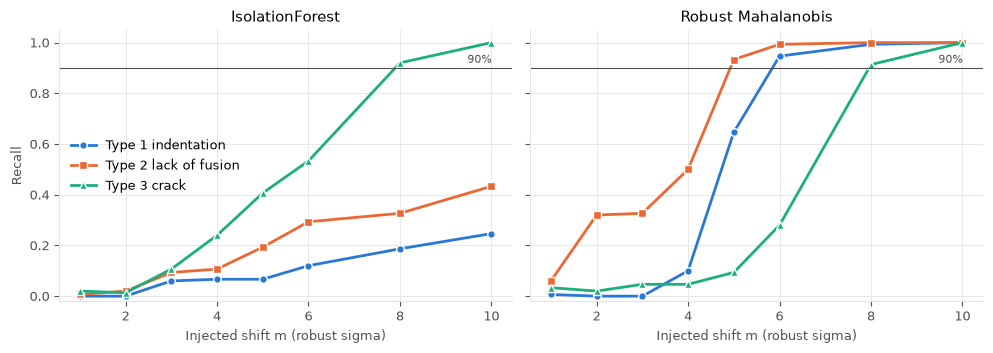

,물리 규칙 유형 정확도,GMM 유형 정확도(최적 매핑)
m,,
1,0.62,0.39
2,0.78,0.75
3,0.91,0.87
4,0.97,0.98
5,0.99,1.00
6,1.00,1.00
8,1.00,1.00
10,1.00,1.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
names = {1: 'Type 1 indentation', 2: 'Type 2 lack of fusion', 3: 'Type 3 crack'}
for ax, det in zip(axes, DETECTORS):
    for t, col, mk in [(1, C1, 'o'), (2, C2, 's'), (3, C3, '^')]:
        r = rec[(rec.detector == det) & (rec.type == t)]
        ax.plot(r.m, r.recall, color=col, lw=2, marker=mk, ms=5.5, label=names[t],
                markeredgecolor='white', markeredgewidth=1)
    ax.axhline(0.9, color=INK2, lw=0.8)
    ax.text(MAGS[-1], 0.91, '90%', ha='right', va='bottom', color=INK2, fontsize=8)
    ax.set_title(det); ax.set_xlabel('Injected shift m (robust sigma)'); ax.set_ylim(-0.02, 1.05)
axes[0].set_ylabel('Recall'); axes[0].legend(frameon=False, loc='center left')
plt.tight_layout(); plt.show()

display(pd.DataFrame(typ_rows).set_index('m').round(2)
        .rename(columns={'physics_rule': '물리 규칙 유형 정확도', 'gmm_best_mapping': 'GMM 유형 정확도(최적 매핑)'}))

**해석 포인트** (수치는 위 표 참고)

- **탐지 한계가 곧 실패조건**입니다. 같은 크기(m)의 이탈이라도 유형(방향)과 탐지기에 따라 탐지율이 크게 다릅니다.
  - IsolationForest는 파임형·용접부족형 이탈을 10σ에서도 절반 이하만 잡습니다. 원인은 바로 아래 셀에서 확인합니다.
  - Robust Mahalanobis는 용접부족형은 5σ, 파임형은 6σ 이상이면 대부분 잡지만, 크랙형(전압↑·가압력↓)은 약 8σ가 되어야 잡힙니다. 대신 held-out 정상 데이터의 오경보율이 IF보다 높습니다(위 출력 참고).
- 이런 모델 간 차이는 **일별 개수로는 전혀 보이지 않습니다.** 사용 중인 Autoencoder나 윈도우 기반 스파이크 탐지도 `DETECTORS`에 점수 함수 하나로 추가하면 같은 기준으로 비교할 수 있습니다.
- **유형 분류**(탐지 여부와 무관하게 주입된 전체 점 기준): GMM은 군집의 모양과 크기로 나눌 뿐 불량 메커니즘을 모릅니다. 위 GMM 정확도는 사후적으로 가장 유리하게 짝지은 최선의 경우입니다. 물리 규칙 기반 판정은 작은 이탈(1σ)에서 더 정확하고, "왜 이 유형인가"를 설명할 수 있습니다. 다만 주입 패턴과 규칙이 같은 가정에서 나왔으므로 이 비교는 **일관성 확인**이지 정답 보장이 아닙니다.

### 4-1. IsolationForest의 실패조건: 학습 범위 밖에서 점수가 포화된다

In [10]:
probe = pd.DataFrame({'force': [2.33, 2.40, 2.45, 2.6, 3.0, 5.0, 10.54]}).assign(
    current=center['current'], voltage=center['voltage'], wtime=center['wtime'])
probe['IsolationForest'] = DETECTORS['IsolationForest'](probe).round(3)
probe['IF 경보'] = probe['IsolationForest'] > THR['IsolationForest']
probe['Robust Mahalanobis'] = DETECTORS['Robust Mahalanobis'](probe).round(1)
probe['MCD 경보'] = probe['Robust Mahalanobis'] > THR['Robust Mahalanobis']
display(probe)
hf = raw[raw['force'] > 3]
print(f"가압력 > 3 bar 인 {len(hf)}행 중 경보: IF {(DETECTORS['IsolationForest'](hf) > THR['IsolationForest']).sum()}행, "
      f"Robust Mahalanobis {(DETECTORS['Robust Mahalanobis'](hf) > THR['Robust Mahalanobis']).sum()}행")

,force,current,voltage,wtime,IsolationForest,IF 경보,Robust Mahalanobis,MCD 경보
0,2.33,14.73,2.702,72.0,0.379,False,0.8,False
1,2.40,14.73,2.702,72.0,0.490,False,14.4,False
2,2.45,14.73,2.702,72.0,0.490,False,35.5,False
3,2.60,14.73,2.702,72.0,0.490,False,156.0,True
4,3.00,14.73,2.702,72.0,0.490,False,896.7,True
5,5.00,14.73,2.702,72.0,0.490,False,13749.0,True
6,10.54,14.73,2.702,72.0,0.490,False,128963.7,True


가압력 > 3 bar 인 1164행 중 경보: IF 832행, Robust Mahalanobis 1164행


나머지 변수가 정상일 때 IsolationForest 점수는 가압력이 2.4 bar든 **10.54 bar(정상의 약 4.5배)** 든 똑같습니다.
IF의 분할 기준값은 학습 데이터의 최솟값과 최댓값 사이에서만 뽑히기 때문에, 범위 밖의 점은 가장자리 점과 같은 깊이에서 고립됩니다. 즉 **이탈의 크기를 구분하지 못합니다.**
실제 데이터의 고가압 행 상당수도 IF로는 경보가 나지 않습니다. 정상 데이터로 IF를 학습하는 구성에서는 이것을 실패조건으로 명시하거나, 거리 기반 점수(Mahalanobis 등)와 함께 써야 합니다.

## 5. 실제 데이터 적용과 안정 공정 범위

### 5-1. 이상 ≠ 불량: 탐지 결과를 일별로 보기

In [11]:
det_name = 'Robust Mahalanobis'           # 4-1의 포화 문제 때문에 거리 기반 점수를 사용
raw['score'] = DETECTORS[det_name](raw)
raw['flag'] = raw['score'] > THR[det_name]
flags = raw.groupby('d').agg(n=('flag', 'size'), flagged=('flag', 'sum'))
flags['defects(label)'] = Y.sum(axis=1)
display(flags)

,n,flagged,defects(label)
d,,,
03-24,1200,10,4.0
03-25,1352,372,8.0
03-26,1000,2,7.0
03-27,1648,372,NaN
03-30,1470,2,4.0
03-31,1800,372,5.0
04-02,2000,2,4.0
04-03,800,372,4.0
04-07,669,0,3.0


경보는 고가압 복사 구간이 있는 4일(03-25, 03-27, 03-31, 04-03)에 수백 건씩 몰리고, 나머지 날은 거의 0건입니다.
그런데 라벨상 그 4일의 불량은 4~8건으로 다른 날(3~7건)과 비슷합니다.

### 5-2. 라벨로 임계값을 보정하면? 하한 대비로 보고하기

In [12]:
def count_report(pred, Y=Y, floor=None):
    # 유형별 예측 개수(일자×유형)를 이론적 하한, 그리고 '8일 평균을 찍는' 기준선과 비교
    pred = pred.reindex(index=Y.index, columns=[1, 2, 3]).fillna(0)
    err = np.abs(pred.values - Y.values).sum()
    naive = np.abs(Y.values - Y.values.mean(axis=0)).sum()
    floor = floor if floor is not None else np.abs(predict_counts(fit_counts(LAB_DAYS, Y), LAB_DAYS).values - Y.values).sum()
    print(f'유형별 개수 오차 = {err:.1f} | 이론적 하한 = {floor:.0f} | 정보 없음 기준선(8일 평균) = {naive:.1f}')
    return err

# 경보율 보정: 라벨 기간 총 경보 수가 총 불량 수(39)와 같아지도록 임계값 1개만 조정
lab = raw[raw['d'].isin(LAB_DAYS)]
thr_cal = np.sort(lab['score'].values)[::-1][int(Y.values.sum()) - 1]
cal = raw[raw['score'] >= thr_cal].copy()
cal['ptype'] = physics_type(cal)
pred = cal.groupby(['d', 'ptype']).size().unstack(fill_value=0)
display(pd.concat([Y.add_prefix('실제_'), pred.reindex(ALL_DAYS, fill_value=0).add_prefix('예측_')], axis=1))
_ = count_report(pred)

,실제_1,실제_2,실제_3,예측_1
03-24,2.0,1.0,1.0,0
03-25,3.0,2.0,3.0,13
03-26,3.0,2.0,2.0,0
03-30,1.0,2.0,1.0,0
03-31,2.0,3.0,0.0,13
04-02,1.0,1.0,2.0,0
04-03,2.0,1.0,1.0,13
04-07,0.0,1.0,2.0,0
03-27,NaN,NaN,NaN,13


유형별 개수 오차 = 64.0 | 이론적 하한 = 10 | 정보 없음 기준선(8일 평균) = 17.5


경보율을 총 불량 수에 맞춰도 경보는 전부 고가압 구간이 있는 날로 가고, 개수 오차는 **평균을 찍는 기준선보다 훨씬 나빠집니다.**
주어진 라벨은 "공정 이탈이 클수록 불량이 많다"는 가설과도 맞지 않습니다. 가압력이 최대 10.54 bar까지 벗어난 날의 불량이 다른 날과 비슷하기 때문입니다.

따라서 **일별 개수에 맞추려고 모델을 튜닝하면 10 bar 과가압 같은 명백한 이탈을 무시하는 방향으로 끌려갑니다.** 이것은 공정 관점에서 받아들이기 어렵습니다.
결론은 두 가지입니다.
- 불량 예측 모델의 타당성은 용접 물리와 합성 주입 검증(4장)으로 주장합니다.
- 일별 개수는 `count_report`처럼 **하한과 기준선을 함께 제시하는 정합성 점검**으로만 보고하고, 불일치의 원인(복사 구조, 포함관계 모순, 이탈일의 라벨 미반영)을 명시합니다.

### 5-3. 안정 공정 조건 범위(제안)

정상 기준 데이터에서 **탐지기가 정상으로 판단한 용접**의 0.5~99.5% 분위 범위를, 전체 관측 범위 및 데이터 설명서의 수집 범위와 비교합니다.
(두께 0.7 mm + 0.7 mm, 단일 설비·품목 조건에서만 유효합니다.)

In [13]:
ok = ref[~(DETECTORS[det_name](ref) > THR[det_name])].astype(float)
ok = ok.assign(heat=ok.current * ok.voltage * ok.wtime, resist=ok.voltage / ok.current * 1000)
allv = raw[F].astype(float)
allv = allv.assign(heat=allv.current * allv.voltage * allv.wtime, resist=allv.voltage / allv.current * 1000)
window = pd.DataFrame({'정상 중앙값': ok.median(), '권장 하한(P0.5)': ok.quantile(0.005), '권장 상한(P99.5)': ok.quantile(0.995),
                       '전체 관측 범위': [f'{allv[c].min():.3f} ~ {allv[c].max():.3f}' for c in allv.columns]})
window['수집 범위(설명서)'] = ['1.00~12.00', '12.00~18.00', '1.50~3.50', '30~120', '-', '-']
window.index = ['가압력(bar)', '전류(kA)', '전압(V)', '통전시간(ms)', '입열 지표 I·V·t (J)', '동저항 V/I (μΩ)']
display(window.round(3))
out = raw[raw['d'].isin(LAB_DAYS)].copy()
inside = np.ones(len(out), bool)
for c, lo, hi in zip(F, window['권장 하한(P0.5)'].iloc[:4], window['권장 상한(P99.5)'].iloc[:4]):
    inside &= out[c].between(lo, hi).values
print(f'라벨 기간 용접 중 권장 범위 안: {inside.mean():.1%}')

,정상 중앙값,권장 하한(P0.5),권장 상한(P99.5),전체 관측 범위,수집 범위(설명서)
가압력(bar),2.320,2.170,2.390,1.740 ~ 10.540,1.00~12.00
전류(kA),14.730,14.530,14.800,14.520 ~ 15.070,12.00~18.00
전압(V),2.702,2.691,2.714,2.464 ~ 2.861,1.50~3.50
통전시간(ms),72.000,70.000,73.000,70.000 ~ 73.000,30~120
입열 지표 I·V·t (J),2844.324,2763.169,2916.500,2580.424 ~ 3105.473,-
동저항 V/I (μΩ),183.577,182.283,186.323,166.150 ~ 193.148,-


라벨 기간 용접 중 권장 범위 안: 83.9%


## 6. 정리: 보고서에 쓸 수 있는 논리

1. **데이터 진단**: 11,939행은 1,574개의 고유 조건으로 이루어져 있고, 날짜들은 공통 구간을 복사해 붙인 구조입니다(03-26 ⊂ 03-30, 04-03 ⊂ 03-25·03-31 등).
2. **검증 한계의 정량화**: 공정 변수 기반 모델의 일별·유형별 개수 오차에는 MILP로 증명한 **하한(10, 총 불량 39건 기준)** 이 있습니다. 라벨 Leave-one-day-out에서도 라벨 기반 모델은 평균 예측을 넘지 못합니다. 따라서 일별 개수는 모델 선택 기준이 될 수 없습니다.
3. **대안 검증**: 중복 제거 후 정상 기준 데이터를 정의하고, 합성 불량 주입으로 유형·크기별 탐지 한계를 측정합니다. 이것이 모델의 **실패조건**입니다(예: IsolationForest의 범위 밖 점수 포화, Mahalanobis의 크랙형 둔감).
4. **유형 판정**: 비지도 GMM 대신 용접 물리(입열 I·V·t, 동저항 V/I, 가압력) 기반 규칙을 사용해 결과를 설명할 수 있게 합니다.
5. **라벨의 역할**: 하한과 기준선을 함께 제시하는 정합성 점검으로만 사용하고, 라벨이 공정 이탈을 반영하지 않는 점을 명시합니다.
6. **안정 공정 범위**: 정상 판정 용접의 분위 범위를 제시하고, 고가압 이탈 구간(최대 10.54 bar)은 별도의 공정 이탈로 보고합니다.